# Evaluate Face Attribute Model



In [1]:
from __future__ import annotations

import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from systems.static_auto_tryon.auto_app.ml.datasets import MultiAttributeDataset, read_jsonl_manifest
from systems.static_auto_tryon.auto_app.ml.inference import load_hairstyle_attribute_checkpoint
from systems.static_auto_tryon.auto_app.ml.transforms import ResizeImage

PROJECT_ROOT


WindowsPath('.')

In [2]:
DATASET_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'datasets' / 'celeba_face_strong'
VAL_MANIFEST = DATASET_ROOT / 'val.jsonl'
CHECKPOINT_PATH = PROJECT_ROOT / 'backend' / 'models' / 'celeba_face_strong' / 'face_attribute_model.pt'

IMAGE_SIZE = 224
BATCH_SIZE = 64
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IMAGE_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celeba' / 'img_align_celeba' / 'img_align_celeba'
if not IMAGE_ROOT.exists():
    IMAGE_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celeba' / 'img_align_celeba'


In [3]:
val_records = read_jsonl_manifest(VAL_MANIFEST)
record_lookup = {str(row.get('source_id', idx)): row for idx, row in enumerate(val_records)}
model, inverse_vocab, face_fields, payload = load_hairstyle_attribute_checkpoint(CHECKPOINT_PATH, device=DEVICE)
label_vocab = payload['label_vocab']
history = pd.DataFrame(payload.get('history', []))

transform = ResizeImage((IMAGE_SIZE, IMAGE_SIZE))
val_dataset = MultiAttributeDataset(
    val_records,
    label_vocab=label_vocab,
    transform=transform,
    fields=face_fields,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def evaluate_attribute_model(model, loader, fields, inverse_vocab, device):
    model.eval()
    total_samples = 0
    exact_correct = 0
    field_correct = {field: 0 for field in fields}
    rows = []

    with torch.inference_mode():
        for batch in loader:
            images = batch['image'].to(device)
            targets = {field: batch['labels'][field].to(device) for field in fields}
            outputs = model(images)

            batch_size = images.shape[0]
            total_samples += batch_size
            batch_all_correct = torch.ones(batch_size, dtype=torch.bool, device=device)
            decoded = {}

            for field in fields:
                probabilities = torch.softmax(outputs[field], dim=1)
                confidence, pred_index = probabilities.max(dim=1)
                true_index = targets[field]
                correct_mask = pred_index.eq(true_index)
                field_correct[field] += int(correct_mask.sum().item())
                batch_all_correct &= correct_mask
                decoded[field] = {
                    'pred_index': pred_index.cpu(),
                    'true_index': true_index.cpu(),
                    'confidence': confidence.cpu(),
                }

            exact_correct += int(batch_all_correct.sum().item())

            for sample_idx, source_id in enumerate(batch['source_id']):
                row = {'source_id': str(source_id)}
                per_sample_correct = True
                confidence_values = []
                for field in fields:
                    pred_index = int(decoded[field]['pred_index'][sample_idx].item())
                    true_index = int(decoded[field]['true_index'][sample_idx].item())
                    confidence = float(decoded[field]['confidence'][sample_idx].item())
                    pred_label = inverse_vocab[field][pred_index]
                    true_label = inverse_vocab[field][true_index]
                    correct = pred_label == true_label
                    per_sample_correct &= correct
                    confidence_values.append(confidence)
                    row[f'pred_{field}'] = pred_label
                    row[f'true_{field}'] = true_label
                    row[f'correct_{field}'] = correct
                    row[f'confidence_{field}'] = confidence
                row['all_correct'] = per_sample_correct
                row['mean_confidence'] = float(np.mean(confidence_values))
                rows.append(row)

    prediction_frame = pd.DataFrame(rows)
    summary = {
        'exact_match_accuracy': exact_correct / max(total_samples, 1),
        'mean_field_accuracy': float(np.mean([field_correct[field] / max(total_samples, 1) for field in fields])),
        **{field: field_correct[field] / max(total_samples, 1) for field in fields},
    }
    return summary, prediction_frame

summary_metrics, prediction_frame = evaluate_attribute_model(
    model=model,
    loader=val_loader,
    fields=face_fields,
    inverse_vocab=inverse_vocab,
    device=DEVICE,
)

pd.Series({
    'val_records': len(val_records),
    'history_rows': len(history),
    'device': DEVICE,
    'architecture': payload.get('architecture'),
    'best_epoch': payload.get('best_epoch'),
    **summary_metrics,
})


val_records                18517
history_rows                  12
device                      cuda
architecture            resnet34
best_epoch                    12
exact_match_accuracy    0.764865
mean_field_accuracy     0.933899
gender                  0.985149
face_fullness           0.955608
cheekbones              0.862127
hairline                 0.93271
dtype: object

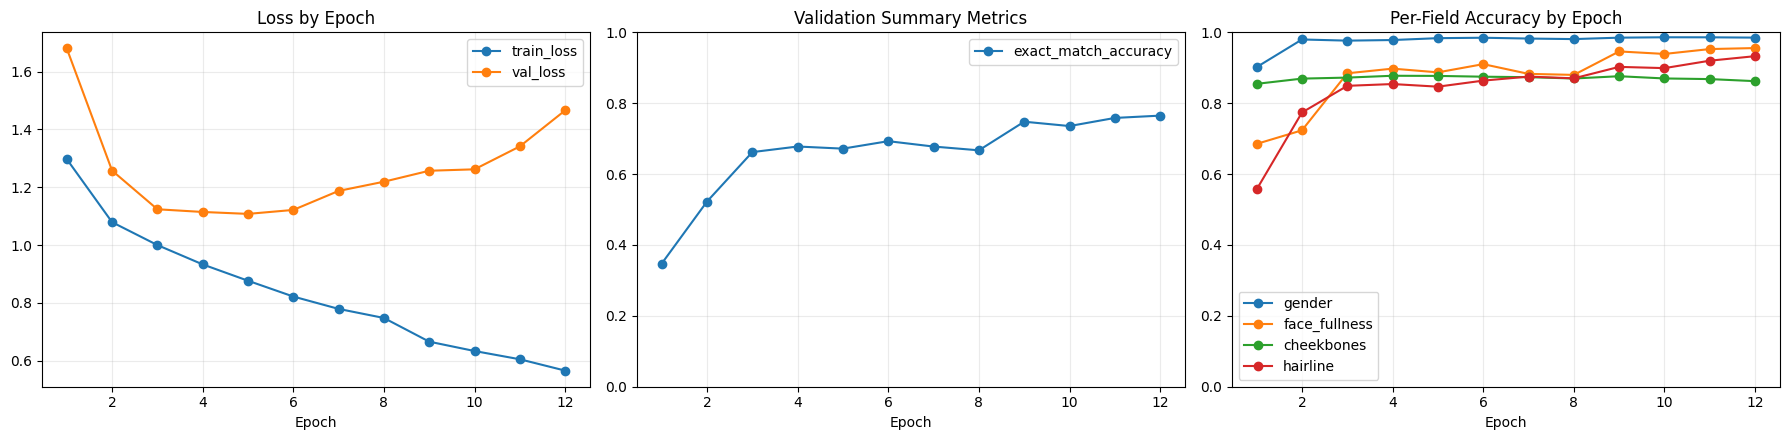

,epoch,train_loss,val_loss,exact_match_accuracy,gender,face_fullness,cheekbones,hairline,learning_rate,epoch_time,best_epoch_so_far,best_exact_match_so_far
7,8,0.747477,1.219140,0.667063,0.980936,0.879894,0.869741,0.870173,0.000150,28:12,6,0.6929
8,9,0.665483,1.257076,0.747853,0.984987,0.946104,0.876168,0.902522,0.000150,27:58,9,0.7479
9,10,0.633104,1.262008,0.735540,0.986067,0.939029,0.869849,0.899012,0.000150,28:22,9,0.7479
10,11,0.604536,1.341418,0.758438,0.985959,0.952800,0.868067,0.919965,0.000075,28:24,11,0.7584
11,12,0.565294,1.466007,0.764973,0.985095,0.955608,0.862235,0.932764,0.000075,28:23,12,0.7650


In [4]:
if history.empty:
    print('No training history found in checkpoint payload.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='train_loss')
    if 'val_loss' in history.columns:
        axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='val_loss')
    axes[0].set_title('Loss by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    if 'exact_match_accuracy' in history.columns:
        axes[1].plot(history['epoch'], history['exact_match_accuracy'], marker='o', label='exact_match_accuracy')
    if 'mean_field_accuracy' in history.columns:
        axes[1].plot(history['epoch'], history['mean_field_accuracy'], marker='o', label='mean_field_accuracy')
    axes[1].set_title('Validation Summary Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    for field in face_fields:
        if field in history.columns:
            axes[2].plot(history['epoch'], history[field], marker='o', label=field)
    axes[2].set_title('Per-Field Accuracy by Epoch')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0.0, 1.0)
    axes[2].grid(alpha=0.25)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

history.tail()


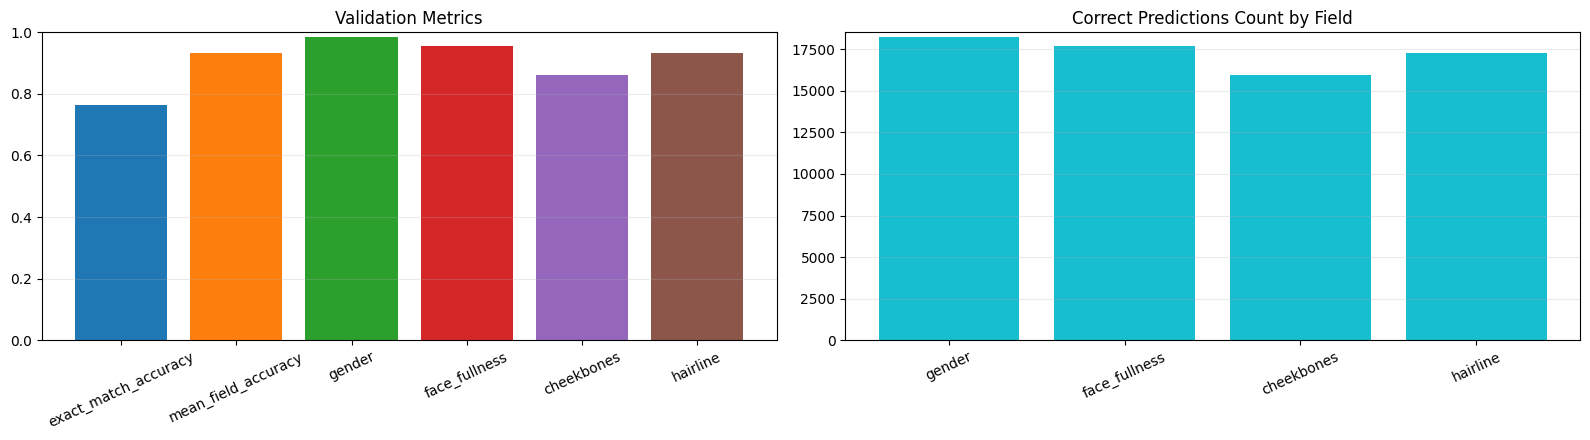

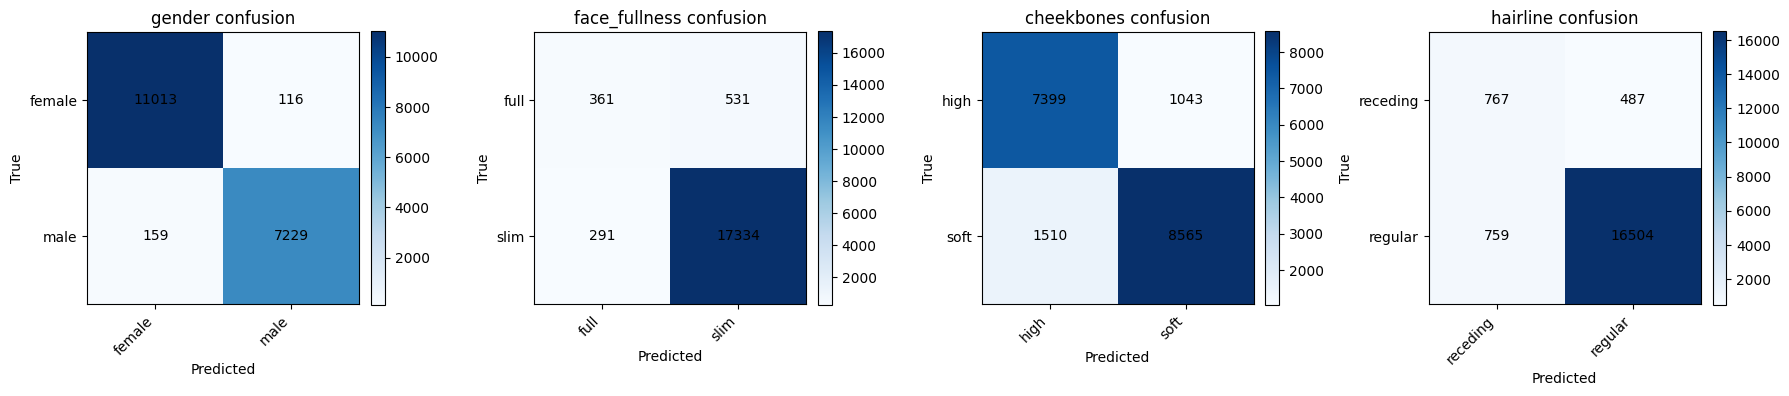

pred_gender,female,male
true_gender,,
female,11013,116
male,159,7229


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

metric_names = ['exact_match_accuracy', 'mean_field_accuracy', *face_fields]
metric_values = [summary_metrics[name] for name in metric_names]
axes[0].bar(metric_names, metric_values, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'][:len(metric_names)])
axes[0].set_title('Validation Metrics')
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25)

correctness = pd.Series({field: int(prediction_frame[f'correct_{field}'].sum()) for field in face_fields})
axes[1].bar(correctness.index, correctness.values, color='tab:cyan')
axes[1].set_title('Correct Predictions Count by Field')
axes[1].set_ylim(0, len(prediction_frame))
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

confusion_frames = {}
fig, axes = plt.subplots(1, len(face_fields), figsize=(4.5 * len(face_fields), 4.5))
if len(face_fields) == 1:
    axes = [axes]

for axis, field in zip(axes, face_fields):
    confusion = pd.crosstab(
        prediction_frame[f'true_{field}'],
        prediction_frame[f'pred_{field}'],
        dropna=False,
    )
    confusion_frames[field] = confusion
    image = axis.imshow(confusion.values, cmap='Blues')
    axis.set_title(f'{field} confusion')
    axis.set_xlabel('Predicted')
    axis.set_ylabel('True')
    axis.set_xticks(range(confusion.shape[1]))
    axis.set_xticklabels(confusion.columns, rotation=45, ha='right')
    axis.set_yticks(range(confusion.shape[0]))
    axis.set_yticklabels(confusion.index)
    for row_idx in range(confusion.shape[0]):
        for col_idx in range(confusion.shape[1]):
            axis.text(col_idx, row_idx, int(confusion.iat[row_idx, col_idx]), ha='center', va='center', color='black')
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

confusion_frames[face_fields[0]]


In [6]:
ranked_examples = prediction_frame.assign(error_count=sum((~prediction_frame[f'correct_{field}']) for field in face_fields))
ranked_examples = ranked_examples.sort_values(['error_count', 'mean_confidence'], ascending=[False, False]).reset_index(drop=True)
ranked_examples.head(10)


,source_id,pred_gender,true_gender,correct_gender,confidence_gender,pred_face_fullness,true_face_fullness,correct_face_fullness,confidence_face_fullness,pred_cheekbones,true_cheekbones,correct_cheekbones,confidence_cheekbones,pred_hairline,true_hairline,correct_hairline,confidence_hairline,all_correct,mean_confidence,error_count
0,167083.jpg,female,male,False,0.591594,slim,full,False,0.771015,high,soft,False,0.983019,receding,regular,False,0.940211,False,0.821459,4
1,179287.jpg,male,male,True,0.990931,full,slim,False,0.971125,high,soft,False,0.964132,receding,regular,False,0.991872,False,0.979515,3
2,167157.jpg,male,male,True,0.989760,full,slim,False,0.997144,soft,high,False,0.904671,receding,regular,False,0.994482,False,0.971514,3
3,169368.jpg,male,male,True,0.991142,full,slim,False,0.996673,high,soft,False,0.961259,regular,receding,False,0.851919,False,0.950248,3
4,179726.jpg,male,male,True,0.976143,full,slim,False,0.986106,high,soft,False,0.974382,regular,receding,False,0.821161,False,0.939448,3
5,181727.jpg,male,male,True,0.992200,full,slim,False,0.997001,soft,high,False,0.982311,receding,regular,False,0.748382,False,0.929973,3
6,174246.jpg,male,male,True,0.989974,slim,full,False,0.755630,soft,high,False,0.985592,receding,regular,False,0.984650,False,0.928961,3
7,182069.jpg,female,male,False,0.955205,slim,full,False,0.734043,high,high,True,0.989765,receding,regular,False,0.992351,False,0.917841,3
8,162824.jpg,male,male,True,0.991775,full,slim,False,0.969429,soft,high,False,0.970122,regular,receding,False,0.681972,False,0.903324,3
9,174230.jpg,male,male,True,0.990047,slim,full,False,0.771028,soft,high,False,0.982257,regular,receding,False,0.850343,False,0.898419,3


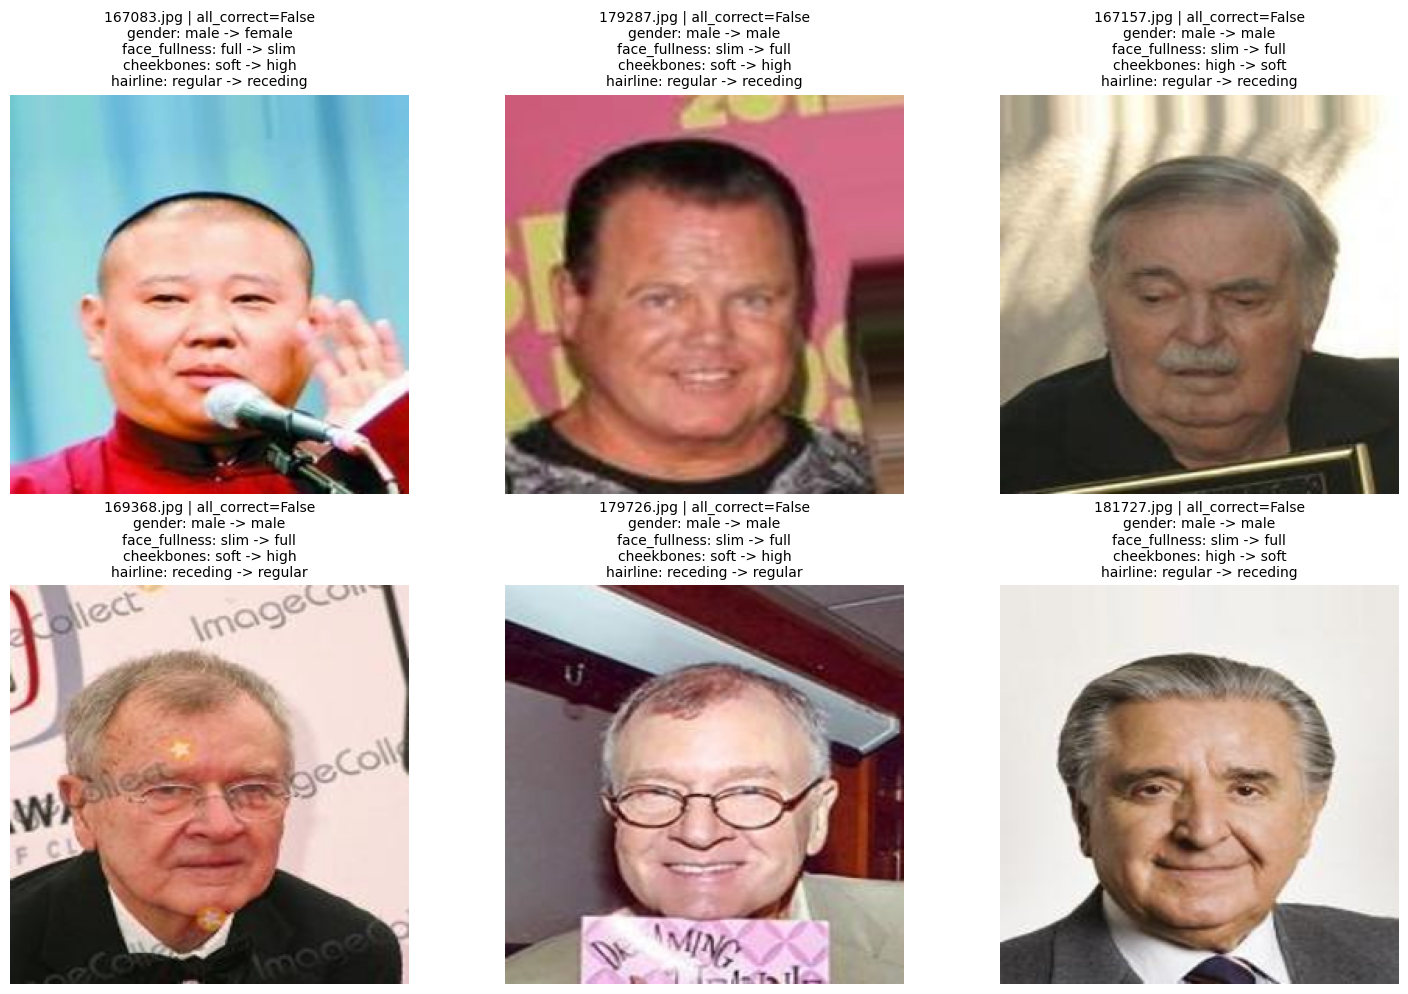

In [7]:
def show_prediction_grid(frame: pd.DataFrame, start_index: int = 0, count: int = 6):
    subset = frame.iloc[start_index:start_index + count]
    columns = min(3, max(len(subset), 1))
    rows = math.ceil(max(len(subset), 1) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 5 * rows))
    axes = np.atleast_1d(axes).reshape(rows, columns)

    for axis in axes.flatten():
        axis.axis('off')

    for axis, (_, row) in zip(axes.flatten(), subset.iterrows()):
        image_path = IMAGE_ROOT / row['source_id']
        if image_path.exists():
            with Image.open(image_path).convert('RGB') as image:
                axis.imshow(image.resize((256, 256)))
        title_lines = [f"{row['source_id']} | all_correct={row['all_correct']}"]
        for field in face_fields:
            title_lines.append(f"{field}: {row[f'true_{field}']} -> {row[f'pred_{field}']}")
        axis.set_title('\n'.join(title_lines), fontsize=10)
        axis.axis('off')

    plt.tight_layout()
    plt.show()

show_prediction_grid(ranked_examples, start_index=0, count=6)
